# Tilted 3D Forward Model on a Cube

This notebook demonstrates the new tilted 3D forward model on a simple uniformly magnetized cube. It renders the 3D object, computes both the axis-aligned and tilted projections, and compares the resulting phase maps.

In [7]:
import os
import sys

os.environ.setdefault("XLA_PYTHON_CLIENT_PREALLOCATE", "false")
os.environ.setdefault("JAX_PLATFORMS", "cpu")

src_path = "/Users/landers/LiberTEM-holo-mbir/src"
if src_path not in sys.path:
    sys.path.insert(0, src_path)

import jax
import matplotlib.pyplot as plt
import numpy as np
import pyvista as pv
from matplotlib.colors import TwoSlopeNorm

from libertem_holo.base.mbir import (
    forward_model_3d,
    forward_model_3d_tilted,
    make_quantity,
    project_3d,
    project_3d_tilted,
 )

jax.config.update("jax_enable_x64", True)

%matplotlib inline

## 1. Build a Simple 3D Cube

We create a centered cube in a larger empty volume and assign a constant magnetization vector to every voxel inside the cube.

In [8]:
N = 48
cube_size = 20
pixel_size = make_quantity(5.0, "nm")

rotation_deg = 30.0
tilt_deg = 20.0
rotation = np.deg2rad(rotation_deg)
tilt = np.deg2rad(tilt_deg)

cube_start = (N - cube_size) // 2
cube_stop = cube_start + cube_size

mask = np.zeros((N, N, N), dtype=bool)
mask[cube_start:cube_stop, cube_start:cube_stop, cube_start:cube_stop] = True

mag = np.zeros((N, N, N, 3), dtype=np.float64)
mag_vector = np.array([1.0, 0.35, 0.15], dtype=np.float64)
mag[mask] = mag_vector
mag_q = make_quantity(mag, "")

print(f"Volume shape: {mag.shape}")
print(f"Cube voxels: {mask.sum()}")
print(f"Magnetization vector inside cube: {mag_vector}")
print(f"Tilt setting: rotation={rotation_deg:.1f} deg, tilt={tilt_deg:.1f} deg")

Volume shape: (48, 48, 48, 3)
Cube voxels: 8000
Magnetization vector inside cube: [1.   0.35 0.15]
Tilt setting: rotation=30.0 deg, tilt=20.0 deg


## 2. Render the Cube in 3D

The rendering uses PyVista in off-screen mode so the notebook stays portable while still giving a proper 3D view.

/tmp/ipykernel_669812/3401546236.py:2: PyVistaDeprecationWarning: This function is deprecated and will be removed in future version of PyVista. Use vtk with osmesa instead.
  pv.start_xvfb()


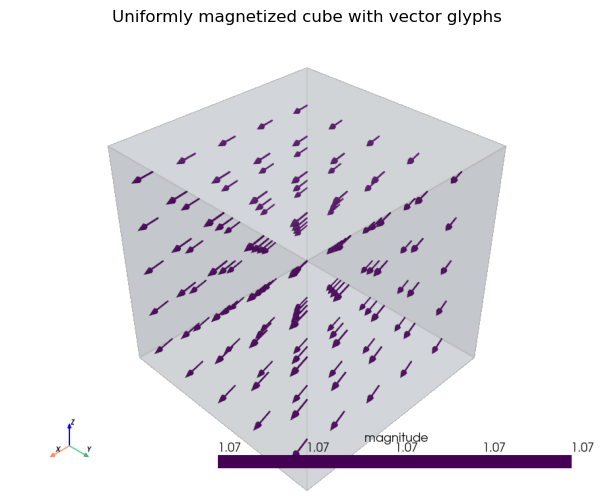

In [9]:
try:
    pv.start_xvfb()
except Exception:
    pass

x0 = cube_start
x1 = cube_stop
y0 = cube_start
y1 = cube_stop
z0 = cube_start
z1 = cube_stop

sample_points = []
for z in range(cube_start + 1, cube_stop, 4):
    for y in range(cube_start + 1, cube_stop, 4):
        for x in range(cube_start + 1, cube_stop, 4):
            sample_points.append((x + 0.5, y + 0.5, z + 0.5))
sample_points = np.asarray(sample_points, dtype=np.float64)
sample_vectors = np.repeat(mag_vector[None, :], len(sample_points), axis=0)

box = pv.Box(bounds=(x0, x1, y0, y1, z0, z1))
cloud = pv.PolyData(sample_points)
cloud["vectors"] = sample_vectors
cloud["magnitude"] = np.linalg.norm(sample_vectors, axis=1)
glyphs = cloud.glyph(orient="vectors", factor=2.5)

plotter = pv.Plotter(off_screen=True, window_size=(900, 700))
plotter.set_background("white")
plotter.add_mesh(box, color="lightsteelblue", opacity=0.18, show_edges=True, line_width=2)
plotter.add_mesh(glyphs, scalars="magnitude", cmap="viridis", ambient=0.4)
plotter.add_axes()
plotter.camera_position = "iso"
render = plotter.screenshot(return_img=True)
plotter.close()

fig, ax = plt.subplots(figsize=(8, 6))
ax.imshow(render)
ax.set_title("Uniformly magnetized cube with vector glyphs")
ax.axis("off")
plt.show()

## 3. Compute Axis-Aligned and Tilted Projections

The axis-aligned version uses the original z-projection. The tilted version uses the new `project_3d_tilted(...)` and `forward_model_3d_tilted(...)` functions.

In [10]:
proj_z = project_3d(mag_q, axis="z")
phase_z = forward_model_3d(mag_q, pixel_size, axis="z")

proj_tilt = project_3d_tilted(mag_q, rotation=rotation, tilt=tilt)
phase_tilt = forward_model_3d_tilted(mag_q, pixel_size, rotation=rotation, tilt=tilt)

print(f"Axis-aligned projected shape: {proj_z.shape}, phase shape: {phase_z.shape}")
print(f"Tilted projected shape: {proj_tilt.shape}, phase shape: {phase_tilt.shape}")
print(f"Axis-aligned phase range: [{np.min(phase_z.value):.4f}, {np.max(phase_z.value):.4f}] rad")
print(f"Tilted phase range: [{np.min(phase_tilt.value):.4f}, {np.max(phase_tilt.value):.4f}] rad")

Axis-aligned projected shape: (48, 48, 2), phase shape: (48, 48)
Tilted projected shape: (62, 57, 2), phase shape: (62, 57)
Axis-aligned phase range: [-4.2581, 4.2581] rad
Tilted phase range: [-3.7104, 3.7104] rad


## 4. Compare the Results

The tilted forward model changes both the projected magnetization field and the resulting phase image.

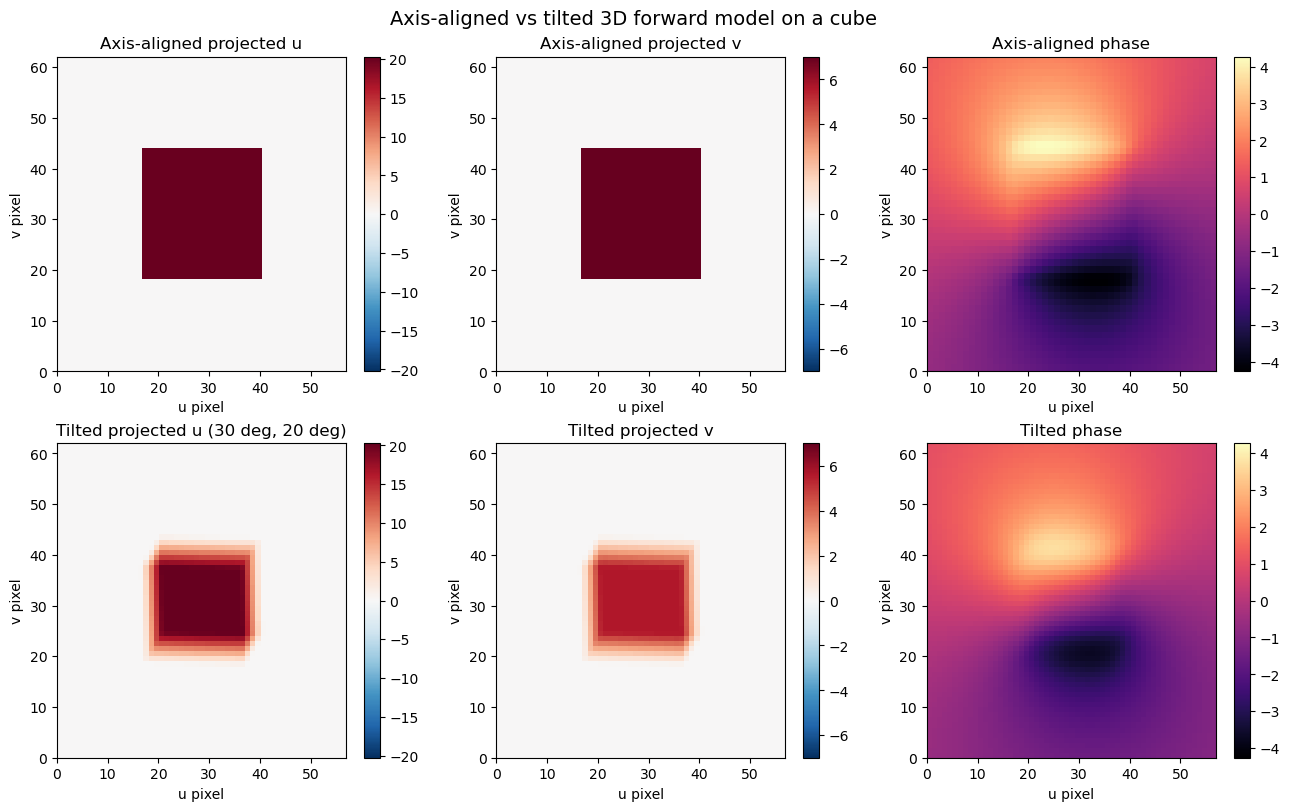

: 

In [ ]:
fig, axs = plt.subplots(2, 3, figsize=(13, 8), constrained_layout=True)

u_abs = max(np.abs(proj_z.value[..., 0]).max(), np.abs(proj_tilt.value[..., 0]).max(), 1e-12)
v_abs = max(np.abs(proj_z.value[..., 1]).max(), np.abs(proj_tilt.value[..., 1]).max(), 1e-12)
phase_abs = max(np.abs(phase_z.value).max(), np.abs(phase_tilt.value).max(), 1e-12)

common_height = max(proj_z.shape[0], proj_tilt.shape[0], phase_z.shape[0], phase_tilt.shape[0])
common_width = max(proj_z.shape[1], proj_tilt.shape[1], phase_z.shape[1], phase_tilt.shape[1])
common_extent = (0, common_width, 0, common_height)

im = axs[0, 0].imshow(
    proj_z.value[..., 0],
    cmap="RdBu_r",
    origin="lower",
    norm=TwoSlopeNorm(0.0, -u_abs, u_abs),
    extent=common_extent,
 )
axs[0, 0].set_title("Axis-aligned projected u")
plt.colorbar(im, ax=axs[0, 0], fraction=0.046)

im = axs[0, 1].imshow(
    proj_z.value[..., 1],
    cmap="RdBu_r",
    origin="lower",
    norm=TwoSlopeNorm(0.0, -v_abs, v_abs),
    extent=common_extent,
 )
axs[0, 1].set_title("Axis-aligned projected v")
plt.colorbar(im, ax=axs[0, 1], fraction=0.046)

im = axs[0, 2].imshow(
    phase_z.value,
    cmap="magma",
    origin="lower",
    vmin=-phase_abs,
    vmax=phase_abs,
    extent=common_extent,
 )
axs[0, 2].set_title("Axis-aligned phase")
plt.colorbar(im, ax=axs[0, 2], fraction=0.046)

im = axs[1, 0].imshow(
    proj_tilt.value[..., 0],
    cmap="RdBu_r",
    origin="lower",
    norm=TwoSlopeNorm(0.0, -u_abs, u_abs),
    extent=common_extent,
 )
axs[1, 0].set_title(f"Tilted projected u ({rotation_deg:.0f} deg, {tilt_deg:.0f} deg)")
plt.colorbar(im, ax=axs[1, 0], fraction=0.046)

im = axs[1, 1].imshow(
    proj_tilt.value[..., 1],
    cmap="RdBu_r",
    origin="lower",
    norm=TwoSlopeNorm(0.0, -v_abs, v_abs),
    extent=common_extent,
 )
axs[1, 1].set_title("Tilted projected v")
plt.colorbar(im, ax=axs[1, 1], fraction=0.046)

im = axs[1, 2].imshow(
    phase_tilt.value,
    cmap="magma",
    origin="lower",
    vmin=-phase_abs,
    vmax=phase_abs,
    extent=common_extent,
 )
axs[1, 2].set_title("Tilted phase")
plt.colorbar(im, ax=axs[1, 2], fraction=0.046)

for ax in axs.flat:
    ax.set_xlim(common_extent[0], common_extent[1])
    ax.set_ylim(common_extent[2], common_extent[3])
    ax.set_xlabel("u pixel")
    ax.set_ylabel("v pixel")

fig.suptitle("Axis-aligned vs tilted 3D forward model on a cube", fontsize=14)
plt.show()